# Dataset Loading 

In [1]:
import pandas as pd
import numpy as np

dataframe = pd.read_csv("../datasets/heart.csv")
dataframe.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Data Exploration and Analysis

In [2]:
dataframe.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [3]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
# Setting 6th row, cholesterol as NULL, to simulate a dataset having a row with null value
dataframe.loc[5, 'Cholesterol'] = np.nan

# Checking null values in a dataset
dataframe.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       1
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
# Printing 4th to 8th rows
dataframe.loc[[3,4,5,6,7]]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,NaN,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.0,0,Normal,142,N,0.0,Up,0


In [6]:
# Dropping null rows (in this case, 6th row. Notice that now total rows is 917)
# inplace=True used to make the change in the dataframe itself, and not return a copy instead
dataframe.dropna(inplace = True) 

In [7]:
dataframe.head(7)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
6,45,F,ATA,130,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.0,0,Normal,142,N,0.0,Up,0


## Plotting

<Axes: xlabel='Cholesterol', ylabel='RestingBP'>

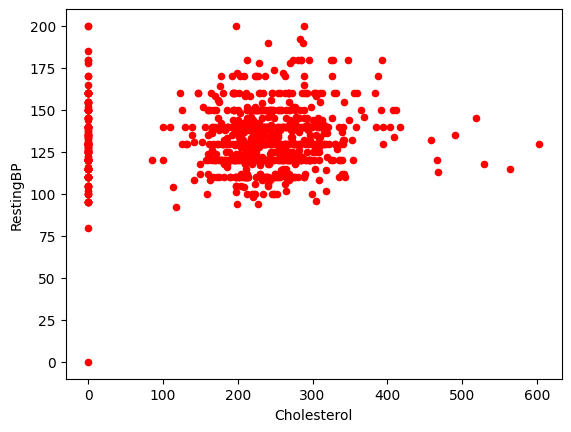

In [8]:
import matplotlib.pyplot as plt

dataframe.plot(kind='scatter', x='Cholesterol' , y='RestingBP', color='red')

***But wait, according to the scatterplot, there are rows with cholesterol 0. This is not realistic, and must be a problem with the dataset. Therefore, all rows with cholesterol 0 must be dropped.***

In [9]:
for x in dataframe.index:
  if dataframe.loc[x, "Cholesterol"] == 0:
    dataframe.drop(x, inplace = True)
    print(f"Row {x} dropped")

Row 293 dropped
Row 294 dropped
Row 295 dropped
Row 296 dropped
Row 297 dropped
Row 298 dropped
Row 299 dropped
Row 300 dropped
Row 301 dropped
Row 302 dropped
Row 303 dropped
Row 304 dropped
Row 305 dropped
Row 306 dropped
Row 307 dropped
Row 308 dropped
Row 309 dropped
Row 310 dropped
Row 311 dropped
Row 312 dropped
Row 313 dropped
Row 314 dropped
Row 315 dropped
Row 316 dropped
Row 317 dropped
Row 318 dropped
Row 319 dropped
Row 320 dropped
Row 321 dropped
Row 322 dropped
Row 323 dropped
Row 324 dropped
Row 325 dropped
Row 326 dropped
Row 327 dropped
Row 328 dropped
Row 329 dropped
Row 330 dropped
Row 331 dropped
Row 332 dropped
Row 333 dropped
Row 334 dropped
Row 335 dropped
Row 336 dropped
Row 337 dropped
Row 338 dropped
Row 339 dropped
Row 340 dropped
Row 341 dropped
Row 342 dropped
Row 343 dropped
Row 344 dropped
Row 345 dropped
Row 346 dropped
Row 347 dropped
Row 348 dropped
Row 349 dropped
Row 350 dropped
Row 351 dropped
Row 352 dropped
Row 353 dropped
Row 354 dropped
Row 355 

In [10]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 745 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             745 non-null    int64  
 1   Sex             745 non-null    object 
 2   ChestPainType   745 non-null    object 
 3   RestingBP       745 non-null    int64  
 4   Cholesterol     745 non-null    float64
 5   FastingBS       745 non-null    int64  
 6   RestingECG      745 non-null    object 
 7   MaxHR           745 non-null    int64  
 8   ExerciseAngina  745 non-null    object 
 9   Oldpeak         745 non-null    float64
 10  ST_Slope        745 non-null    object 
 11  HeartDisease    745 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 91.8+ KB


## Converting Categorical Data to Numerical Data (One Hot Encoding)

In [11]:
dataframe.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
6,45,F,ATA,130,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.0,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207.0,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284.0,0,Normal,120,N,0.0,Up,0
10,37,F,NAP,130,211.0,0,Normal,142,N,0.0,Up,0


In [12]:
# One-Hot Encoding
temp_df = pd.get_dummies(dataframe["Sex"], dtype=int)
temp_df.head()

,F,M
0,0,1
1,1,0
2,0,1
3,1,0
4,0,1


In [13]:
temp_df.drop(columns=["F"],inplace=True)
dataframe.drop(columns=["Sex"], inplace=True)
dataframe = pd.concat([dataframe,temp_df], axis=1)
dataframe.rename(columns={"M":"Sex"}, inplace=True)
dataframe.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex
0,40,ATA,140,289.0,0,Normal,172,N,0.0,Up,0,1
1,49,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1,0
2,37,ATA,130,283.0,0,ST,98,N,0.0,Up,0,1
3,48,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1,0
4,54,NAP,150,195.0,0,Normal,122,N,0.0,Up,0,1


## Converting Categorical Data to Numerical Data (using Label Encoder)

**Some features have more than two categories. These categories must be replaced with 0,1,2,3... before passing to model. To achieve this, sklearn's LabelEncoder is used to replace categorical values with numerical values. The mapping is shown for each replacement.**

In [14]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

dataframe['ChestPainTypeLE'] = LE.fit_transform(dataframe['ChestPainType'])
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'ASY': 0, 'ATA': 1, 'NAP': 2, 'TA': 3}


In [15]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

dataframe['RestingECGLE'] = LE.fit_transform(dataframe['RestingECG'])
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'LVH': 0, 'Normal': 1, 'ST': 2}


In [16]:
# Note that this can be done with One-Hot Encoding as well
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

dataframe['ExerciseAnginaLE'] = LE.fit_transform(dataframe['ExerciseAngina'])
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'N': 0, 'Y': 1}


In [17]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

dataframe['ST_SlopeLE'] = LE.fit_transform(dataframe['ST_Slope'])
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'Down': 0, 'Flat': 1, 'Up': 2}


In [18]:
dataframe.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex,ChestPainTypeLE,RestingECGLE,ExerciseAnginaLE,ST_SlopeLE
0,40,ATA,140,289.0,0,Normal,172,N,0.0,Up,0,1,1,1,0,2
1,49,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1,0,2,1,0,1
2,37,ATA,130,283.0,0,ST,98,N,0.0,Up,0,1,1,2,0,2
3,48,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1,0,0,1,1,1
4,54,NAP,150,195.0,0,Normal,122,N,0.0,Up,0,1,2,1,0,2


In [19]:
dataframe.drop(columns=["ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope" ] , inplace=True)
dataframe.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex,ChestPainTypeLE,RestingECGLE,ExerciseAnginaLE,ST_SlopeLE
0,40,140,289.0,0,172,0.0,0,1,1,1,0,2
1,49,160,180.0,0,156,1.0,1,0,2,1,0,1
2,37,130,283.0,0,98,0.0,0,1,1,2,0,2
3,48,138,214.0,0,108,1.5,1,0,0,1,1,1
4,54,150,195.0,0,122,0.0,0,1,2,1,0,2


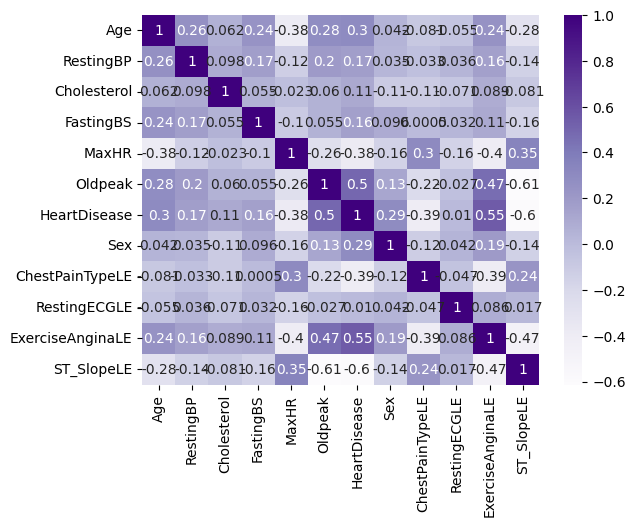

In [20]:
import seaborn as sns

corr_matrix = dataframe.corr()

sns.heatmap(corr_matrix, cmap='Purples', annot=True)

plt.show()

# Train-Test Splitting

In [21]:
from sklearn.model_selection import train_test_split

X = dataframe.drop(['HeartDisease'], axis=1)

y = dataframe['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

# Model Training

## SVM

In [22]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train,y_train)
y_predicted_svm = svm.predict(X_test)
print(y_predicted_svm)

[1 1 0 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1
 1 1 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1
 0 0 0 0 0 1 0 1 0 0 0 1 1 0 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0
 0]


## Decision Tree

## Naive Bayes

## Random Forest 

# Prediction

In [23]:
feature_cols = [
    "Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak", "Sex", "ChestPainTypeLE", 
    "RestingECGLE", "ExerciseAnginaLE", "ST_SlopeLE",
]

## SVM

In [24]:
example1 = {
    "Age"               : 40.0,
    "RestingBP"         : 140.0,
    "Cholesterol"       : 289.0,
    "FastingBS"         :   0.0,
    "MaxHR"             : 172.0,
    "Oldpeak"           :   0.0,
    "Sex"               :   1.0,
    "ChestPainTypeLE"   :   1.0,
    "RestingECGLE"      :   1.0,
    "ExerciseAnginaLE"  :   0.0,
    "ST_SlopeLE"        :   2.0,
}

df_example1 = pd.DataFrame([example1], columns=feature_cols)

prediction1 = svm.predict(df_example1)
print(f"The predicted class by SVM is {prediction1[0]}")

The predicted class by SVM is 0


In [25]:
example2 = {
    "Age"               : 54.0,
    "RestingBP"         : 125.0,
    "Cholesterol"       : 224.0,
    "FastingBS"         :   0.0,
    "MaxHR"             : 122.0,
    "Oldpeak"           :   2.0,
    "Sex"               :   1.0,
    "ChestPainTypeLE"   :   0.0,
    "RestingECGLE"      :   1.0,
    "ExerciseAnginaLE"  :   0.0,
    "ST_SlopeLE"        :   1.0,
}

df_example2 = pd.DataFrame([example2], columns=feature_cols)

prediction2 = svm.predict(df_example2)
print(f"The predicted class by SVM is {prediction2[0]}")

The predicted class by SVM is 1


## Decision Tree

## Naive Bayes

## Random Forest

# Evaluation

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_predicted_svm)
precision = precision_score(y_test, y_predicted_svm, average='macro')
recall = recall_score(y_test, y_predicted_svm, average='macro')
f1 = f1_score(y_test, y_predicted_svm, average='macro')

print("------------------------------")
print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1 Score : {f1}")
print("------------------------------")

------------------------------
Accuracy : 0.6845637583892618
Precision: 0.684814012278801
Recall   : 0.6844144144144144
F1 Score : 0.6843362632409284
------------------------------


## Decision Tree

## Naive Bayes

## Random Forest